In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [2]:
columns = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width",
    "species"
]

data = pd.read_csv(
    "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data",
    header=None,
    names=columns
)

In [3]:
# Remove missing rows
data = data.dropna()

# ================================
# STEP 3: Features & Target
# ================================
X = data.iloc[:, 0:4]
y = data.iloc[:, 4]

# ================================
# STEP 4: Encode Target
# ================================
encoder = LabelEncoder()
y = encoder.fit_transform(y)

# ================================
# STEP 5: Feature Scaling
# ================================
scaler = StandardScaler()
X = scaler.fit_transform(X)

# ================================
# STEP 6: Train-Test Split
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ================================
# STEP 7: Create ANN Model
# ================================
model = MLPClassifier(hidden_layer_sizes=(10, 8), max_iter=1000)

# ================================
# STEP 8: Train Model
# ================================
model.fit(X_train, y_train)

# ================================
# STEP 9: Prediction
# ================================
y_pred = model.predict(X_test)

# ================================
# STEP 10: Evaluation
# ================================
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



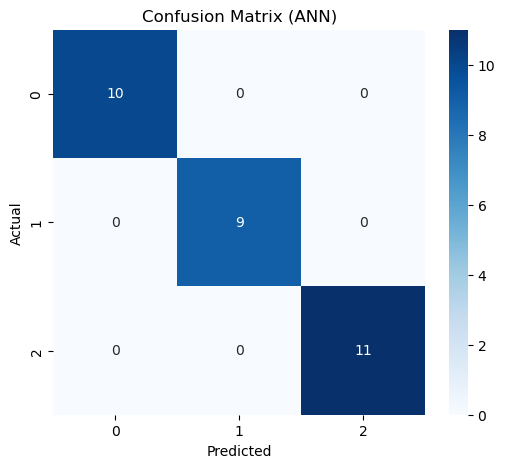

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (ANN)")

plt.show()

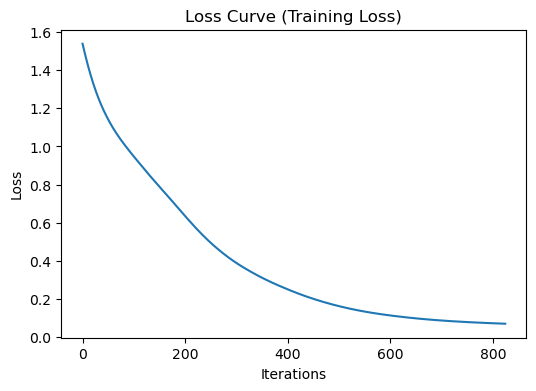

In [5]:
plt.figure(figsize=(6,4))

plt.plot(model.loss_curve_)

plt.title("Loss Curve (Training Loss)")
plt.xlabel("Iterations")
plt.ylabel("Loss")

plt.show()